In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.optimizers import Adam

2.Load Devnagari Dataset Using PIL

In [3]:
data_dir = "/content/drive/MyDrive/AI_ML/Week4/DevanagariHandwrittenDigitDataset/Train/"
img_size = (32, 32)

images = []
labels = []

class_names = sorted(os.listdir(data_dir))

for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path, file_name)
        try:
            img = Image.open(file_path).convert("L")   # grayscale
            img = img.resize(img_size)
            img_array = np.array(img, dtype=np.float32) / 255.0
            images.append(img_array)
            labels.append(class_name)
        except:
            pass

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (16999, 32, 32)
Labels shape: (16999,)


3. Reshape and Split Dataset

In [6]:
images = np.expand_dims(images, axis=-1)   # (N, 32, 32, 1)

X_train, X_val = train_test_split(
    images, test_size=0.2, random_state=42, shuffle=True
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Training shape: (13599, 32, 32, 1)
Validation shape: (3400, 32, 32, 1)


4. Add Noise to Images

In [7]:
noise_factor = 0.5

X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=X_train.shape
)

X_val_noisy = X_val + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=X_val.shape
)

X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0)
X_val_noisy = np.clip(X_val_noisy, 0.0, 1.0)

5. Visualize Original vs Noisy Images

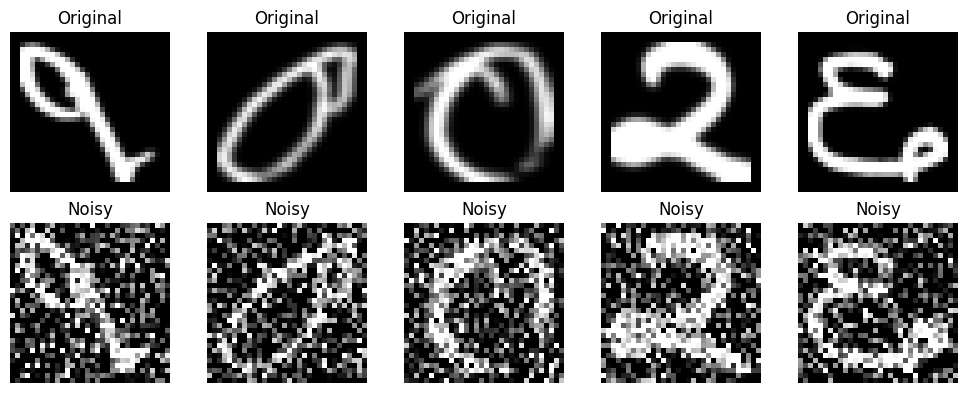

In [8]:
def show_samples(original, noisy, n=5):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        # original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(img_size[0], img_size[1]), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # noisy
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(noisy[i].reshape(img_size[0], img_size[1]), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(X_train, X_train_noisy, n=5)

6. Build the Denoising Convolutional Autoencoder

In [9]:
def build_autoencoder(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

7. Train the Autoencoder

In [10]:
history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(X_val_noisy, X_val)
)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 89s 810ms/step - loss: 0.4040 - val_loss: 0.2677
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 80s 746ms/step - loss: 0.2345 - val_loss: 0.2104
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 81s 761ms/step - loss: 0.1982 - val_loss: 0.1885
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 85s 789ms/step - loss: 0.1833 - val_loss: 0.1778
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 79s 744ms/step - loss: 0.1749 - val_loss: 0.1721
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 80s 744ms/step - loss: 0.1692 - val_loss: 0.1677
Epoch 7/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 86s 807ms/step - loss: 0.1650 - val_loss: 0.1640
Epoch 8/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 80s 752ms/step - loss: 0.1620 - val_loss: 0.1614
Epoch 9/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 81s 760ms/step - loss: 0.1594 - val_loss: 0.1597
Epoch 10/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 86s 799ms/step - loss: 0.1569 - val_loss: 0.1571
Epoch 11/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 81s 756ms/step - loss: 0.1550 - val_loss: 0.1561
Epoch 12/15
107/107

8. Plot Training and Validation Loss

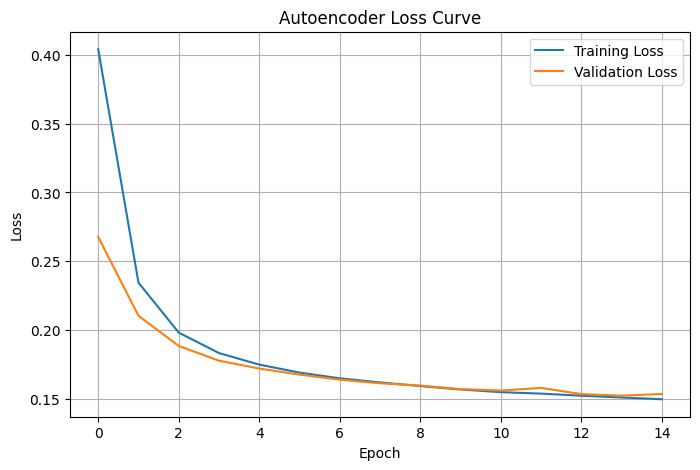

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

9. Predict Denoised Images

In [12]:
denoised_images = autoencoder.predict(X_val_noisy)

107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step


10. Visualize Noisy, Denoised, and Clean Images

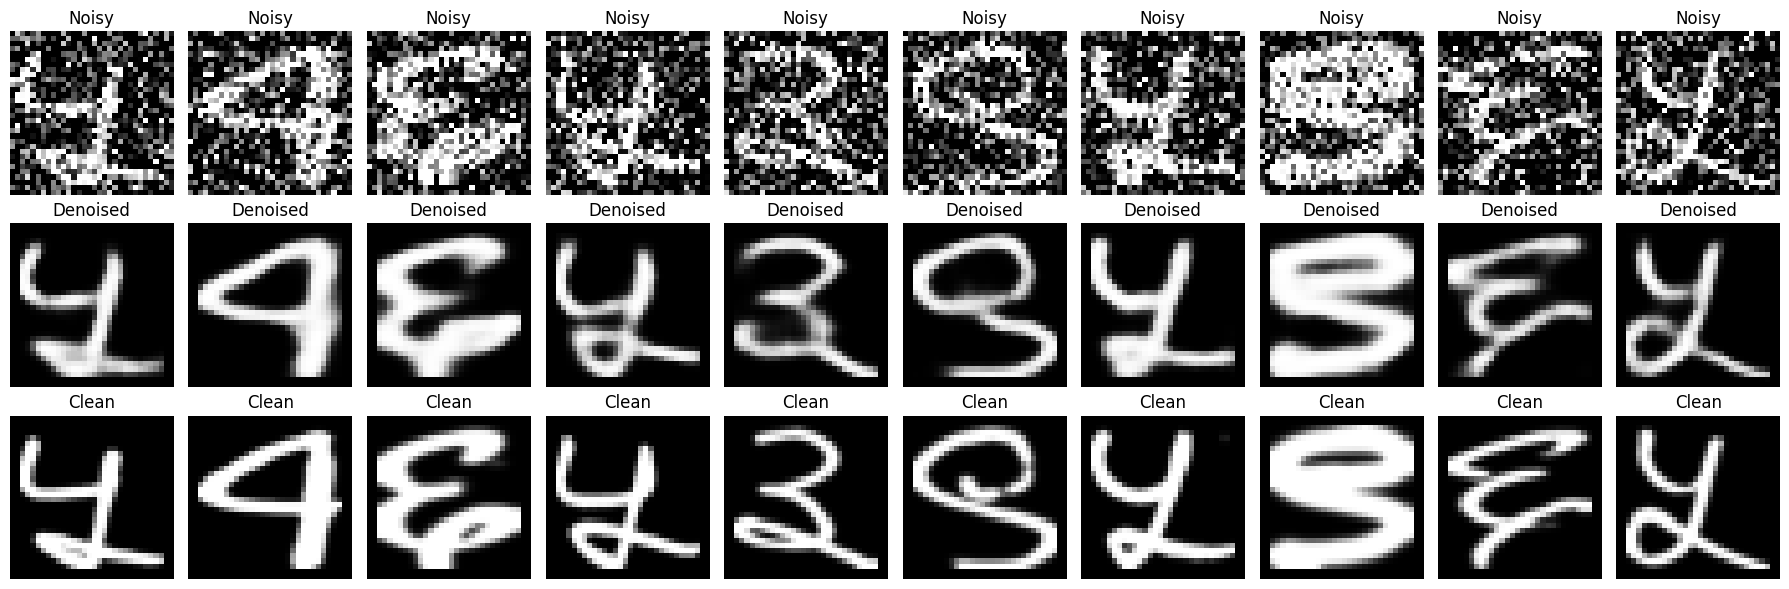

In [13]:
def plot_results(noisy, denoised, clean, n=10):
    plt.figure(figsize=(18, 6))
    for i in range(n):
        # noisy
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(noisy[i].reshape(img_size[0], img_size[1]), cmap='gray')
        plt.title("Noisy")
        plt.axis("off")

        # denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised[i].reshape(img_size[0], img_size[1]), cmap='gray')
        plt.title("Denoised")
        plt.axis("off")

        # clean
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean[i].reshape(img_size[0], img_size[1]), cmap='gray')
        plt.title("Clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_results(X_val_noisy, denoised_images, X_val, n=10)